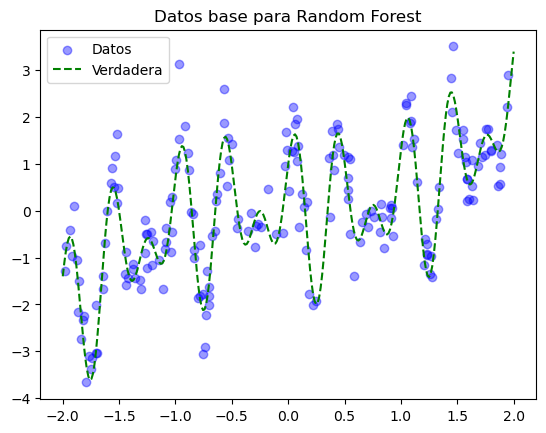

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils import resample

np.random.seed(42)

# Funcion verdadera compleja (para ver reduccion de varianza)
def true_function(x):
    return np.sin(6 * np.pi * x) + np.cos(4 * np.pi * x ) + 0.3 * x**3

N = 200
x = np.sort(np.random.uniform(-2, 2, N))
y = true_function(x) + np.random.normal(0, 0.5, N)

x_test = np.linspace(-2, 2, 300)
y_true = true_function(x_test)

# Grafico base
plt.scatter(x, y, color='blue', alpha=0.4, label='Datos')
plt.plot(x_test, y_true, 'g--', label='Verdadera')
plt.title('Datos base para Random Forest')
plt.legend()
plt.show()

In [5]:
def regression_tree_fit(x, y, max_depth=10, min_samples_split=5, m_features=None):

    """
    Arbol de regresion con seleccion aleatoria de features (para Random Forest).
    Tegnologia inversa: cada split elige solo m features al azar decorrelaciona arboles.
    m_features = None usa todos (bagging puro)
    m_features = int(sqrt(p)) Tipico en Random Forest
    """
    def find_best_split(x, y):
        best_split = None
        best_rss = np.inf

        # Seleccion aleatoria de features (si m_features esta definido)
        features = np.arange(len(x[0])) if m_features is None else np.random.choice(len(x[0]), m_features, replace=False)

        for split in np.unique(x):
            left = x < split
            right = ~left
            if np.sum(left) < min_samples_split or np.sum(right) < min_samples_split:
                continue
            rss_left = np.sum(y[left] - np.mean(y[left])**2)
            rss_right = np.sum((y[right] - np.mean(y[right]))**2)
            rss_total = rss_left + rss_right
            if rss_total < best_rss:
                best_rss = rss_total
                best_split = split
        return best_split

    def build_tree(x, y, depth=0):
        if depth >= max_depth or len(y) < min_samples_split:
            return np.mean(y)  # hoja: de y

        split = find_best_split(x, y)
        if split is None:
            return np.mean(y)

        left = x < split
        right = ~left
        return {
        'split': split,
        'left': build_tree(x[left], y[left], depth + 1),
        'right': build_tree(x[right], y[right], depth + 1)
        }

    return build_tree(x, y)

In [6]:
def random_forest(x, y, B=50, max_depth=10, m_features='sqrt'):
    """
    Random Forest: bagging + selección aleatoria de features en cada split.
    Tecnología inversa: decorrelaciona árboles → reduce varianza más que bagging solo.
    m_features: 'sqrt' (típico), 'log2' o número fijo.
    """
    n_features = x.shape[1] if x.ndim > 1 else 1
    if m_features == 'sqrt':
        m = int(np.sqrt(n_features))
    elif m_features == 'log2':
        m = int(np.log2(n_features))
    else:
        m = m_features
    
    forest = []
    for b in range(B):
        x_boot, y_boot = resample(x, y, replace=True)
        tree = regression_tree_fit(x_boot, y_boot, max_depth=max_depth, m_features=m)
        forest.append(tree)
    return forest

def predict_forest(forest, x_new):
    """
    Predicción: promedio de todos los árboles del bosque.
    """
    predictions = np.array([predict_tree(tree, x_new) for tree in forest])
    return np.mean(predictions)

In [7]:
# Bagging puro (m_features=None → usa todas las features)
forest_bag = random_forest(x[:, np.newaxis], y, B=50, max_depth=10, m_features=None)  # x como 2D

# Random Forest (m_features='sqrt')
forest_rf = random_forest(x[:, np.newaxis], y, B=50, max_depth=10, m_features='sqrt')

# Predicciones
y_bag = np.array([predict_forest(forest_bag, xi) for xi in x_test])
y_rf = np.array([predict_forest(forest_rf, xi) for xi in x_test])

plt.figure(figsize=(12, 6))
plt.scatter(x, y, color='blue', alpha=0.4, label='Datos')
plt.plot(x_test, y_true, 'g--', label='Verdadera')
plt.plot(x_test, y_bag, 'orange', linewidth=2, label='Bagging (50 árboles)')
plt.plot(x_test, y_rf, 'r-', linewidth=2, label='Random Forest (m=sqrt)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Bagging vs Random Forest (Capítulo 7)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed